Make correlation matrix of neurons in explore, project h&e data onto it

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [ ]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from behave_analysis.analyze.CCA.cca_utils import preprocess_behavioral_data, select_train_test_frames, safe_corrcoef, get_correlation_loadings
from behave_analysis.analyze.CCA.find_shelter_exit_and_runs import find_shelter_exit_runs
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import homing_escape_boolean_vectors
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

import os
import numpy as np
from sklearn.cross_decomposition import CCA
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import dill as pickle
%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
COLUMNS_TO_KEEP = ["hdir", "mouse_x_position", "mouse_y_position", "speed", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-04-08 14:25:25.500 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-08 14:30:48.631 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-08 14:35:23.696 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
2026-04-08 14:39:12.605 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-08 14:44:19.199 | INFO     | behave_analysis.process.process:load_session:117 - All data has b

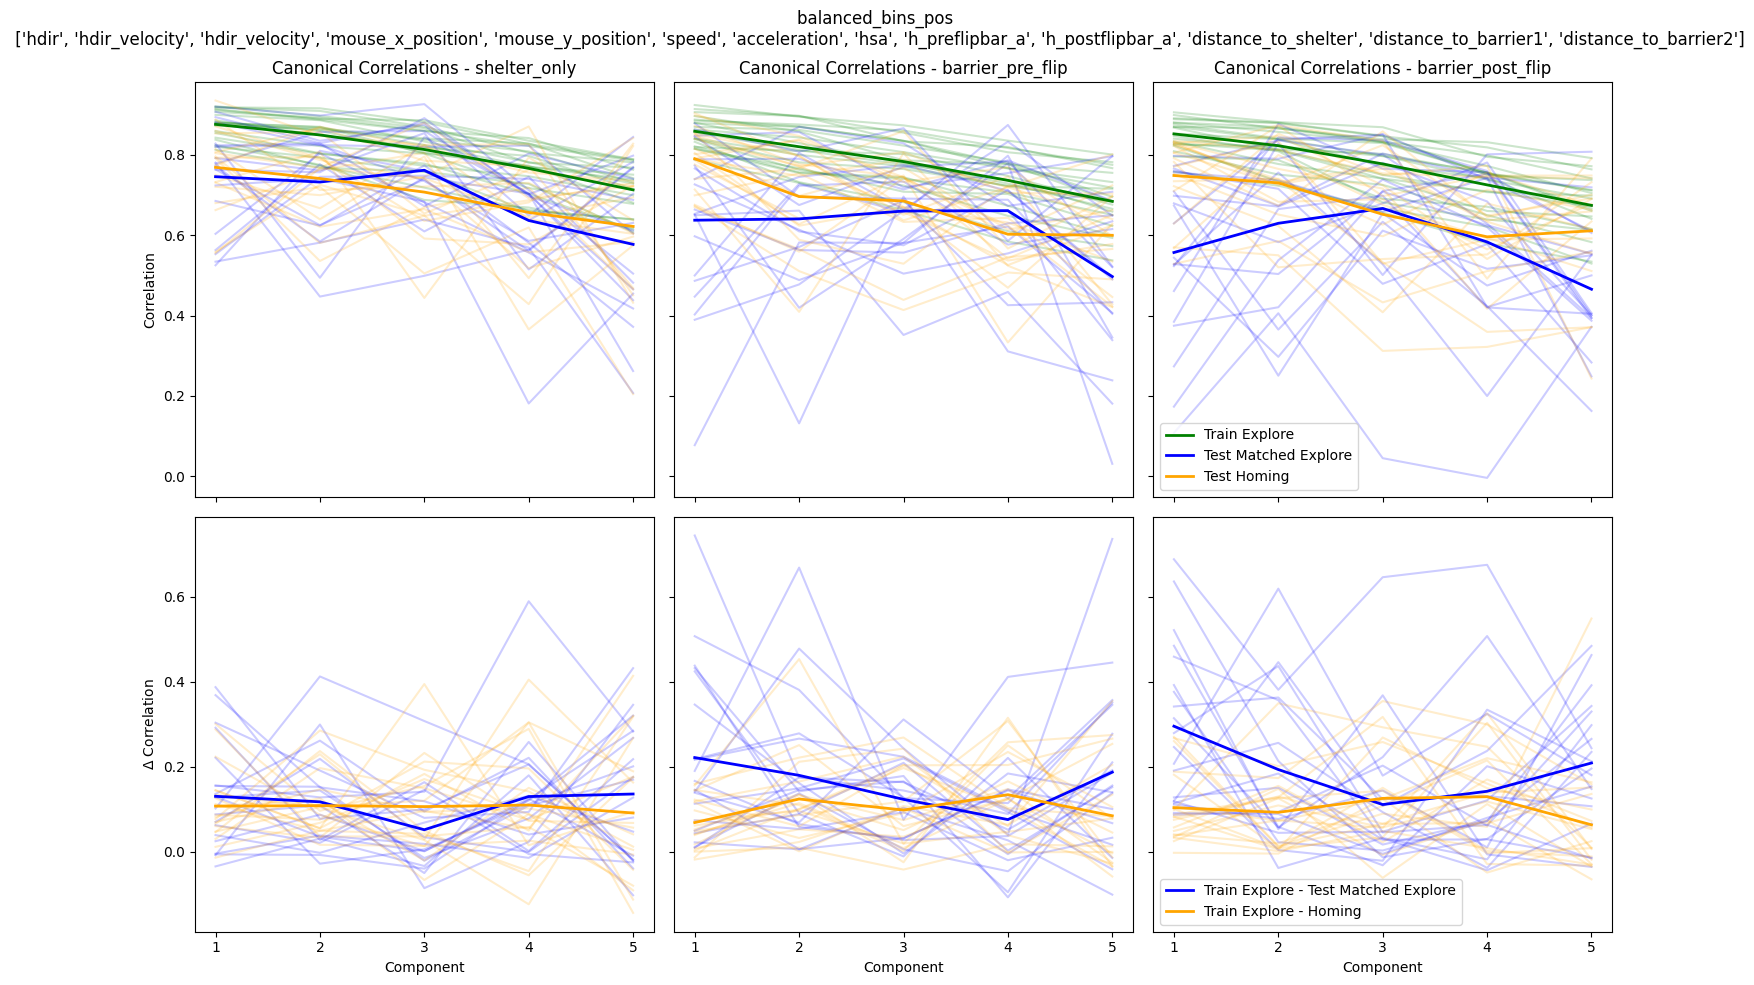

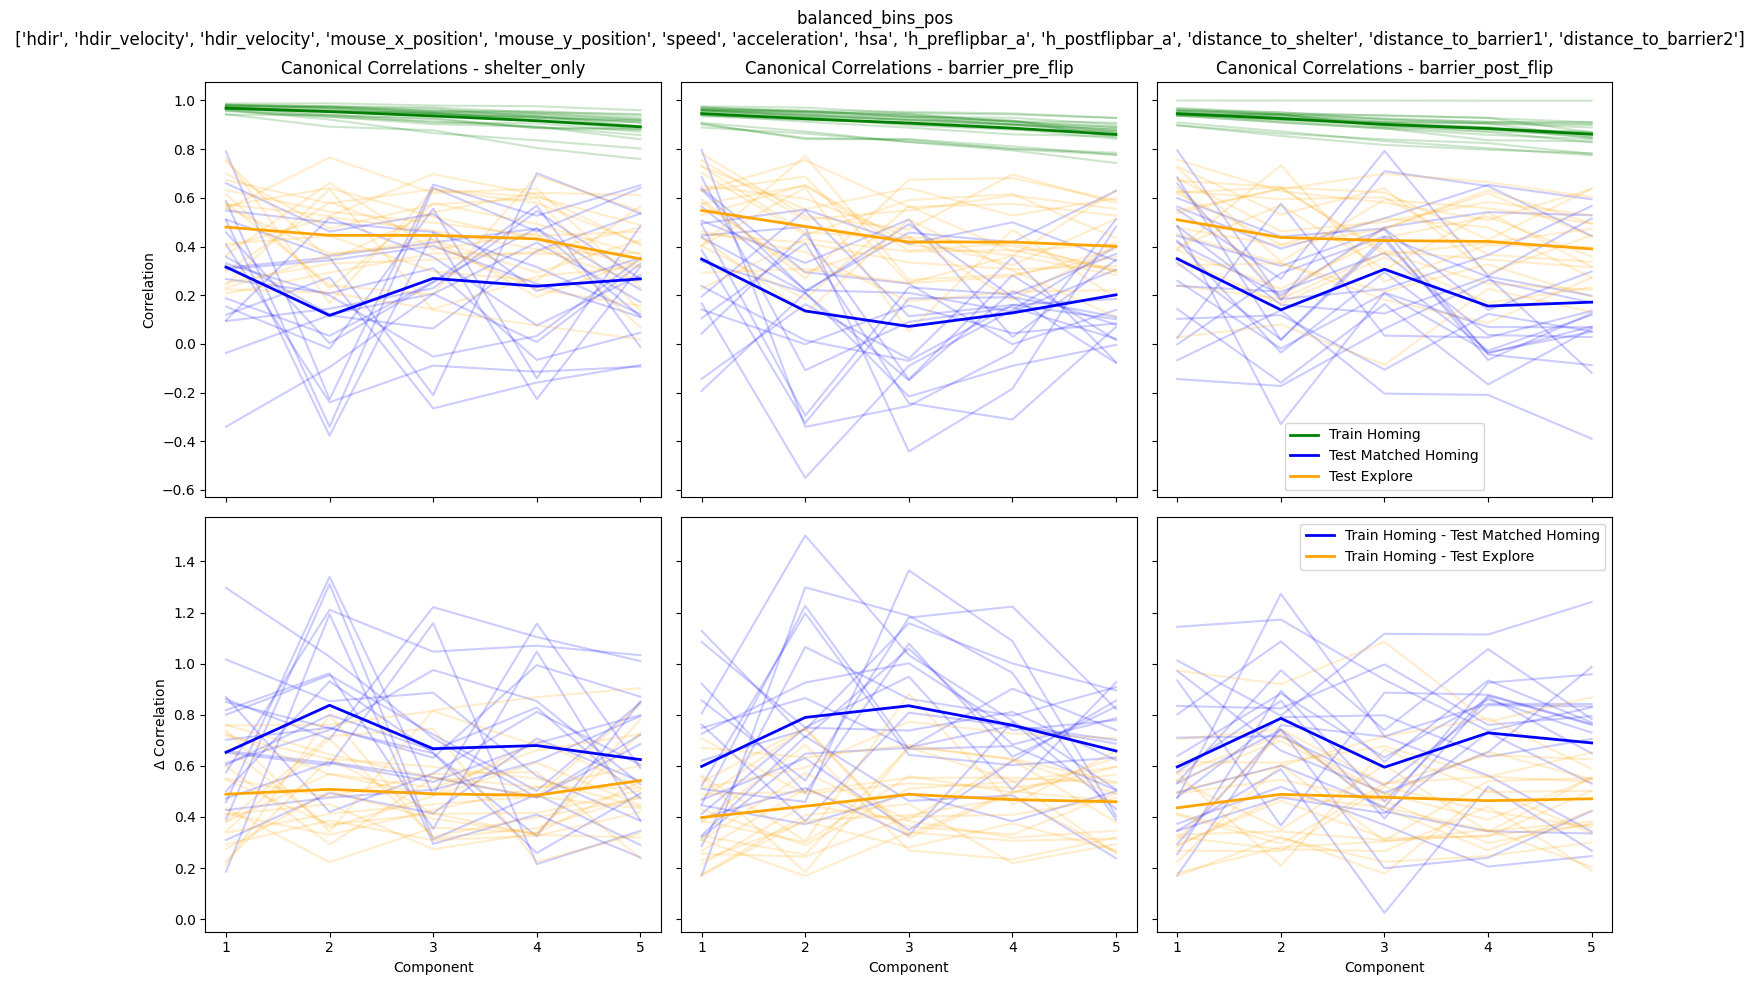

In [77]:
"""Compare CCA 
1. trained on explore and tested on homings and out of shelter runs
2. trained on homings and tested on explore and out of shelter runs"""

COLUMNS_TO_KEEP, filename = ["hdir", "hdir_velocity", "hdir_velocity", "mouse_x_position", "mouse_y_position", "speed", "acceleration", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"], "cca_results_" + method + ".npz"
n_components = 5

train_explore = {'test_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'train_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'homing_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan)}
train_homing = {'exp_match_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'test_exp_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'train_h_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan)}

for e in range(len(experiments_objects)):
    session_name = list(experiments_objects.keys())[e]
    exp = experiments_objects[session_name]
    session = Process(exp).load_session()
    session_start = max(session.shelter_time[0]*60*40, 30*40) # start at shelter_time or 30s, whichever is later
    video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
    fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
    mean_fr = np.nanmean(fcm, axis=0)
    std_fr = np.nanstd(fcm, axis=0)
    fcm_z = (fcm - mean_fr) / std_fr
    assert len(video_df) == fcm.shape[0], "Number of frames in video dataframe does not match number of frames in frame-by-cluster matrix"
    shelter_location = [np.mean([session.shelter_location[0][0], session.shelter_location[1][0]]), session.shelter_location[0][1]]
    video_df = video_df.with_columns(pl.Series("distance_to_shelter", np.sqrt((video_df["mouse_x_position"] - shelter_location[0])**2 + (video_df["mouse_y_position"] - shelter_location[1])**2)))
    video_df = video_df.with_columns(pl.Series("distance_to_barrier1", np.sqrt((video_df["mouse_x_position"] - session.barrier_location[0][0])**2 + (video_df["mouse_y_position"] - session.barrier_location[0][1])**2)))
    video_df = video_df.with_columns(pl.Series("distance_to_barrier2", np.sqrt((video_df["mouse_x_position"] - session.barrier_location[1][0])**2 + (video_df["mouse_y_position"] - session.barrier_location[1][1])**2)))
    Y, col_names = preprocess_behavioral_data(video_df, COLUMNS_TO_KEEP)
    outside_runs = find_shelter_exit_runs(
        video_df,
        min_speed_cm_s=5.0,
        min_distance_cm=20.0,
    )
    train_explore["X_train_loadings"] = {session_name:np.full((3, fcm.shape[1], n_components), np.nan)}
    train_explore["X_test_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_explore["X_homing_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_homing["exp_match_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_homing["test_exp_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_homing["train_h_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    for c, cond in enumerate(cond_list):
        frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
        homing_indices = (
            filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
        )
        explore_test_idx = [idx for idx in frames_by_condition_explore if idx in np.where(outside_runs)[0]]
        explore_train_idx = [idx for idx in frames_by_condition_explore if idx not in explore_test_idx]
        # check that indices don't fall below the session start time
        explore_train_idx = [idx for idx in explore_train_idx if idx >= session_start]
        explore_test_idx = [idx for idx in explore_test_idx if idx >= session_start]
        homing_indices = [idx for idx in homing_indices if idx >= session_start]

        # FIRST WE TRAIN ON EXPLORE, TEST ON HOMING
        A_X_train = fcm_z[explore_train_idx, :]
        A_Y_train = Y[explore_train_idx, :]
        A_X_test = fcm_z[explore_test_idx, :]
        A_Y_test = Y[explore_test_idx, :]
        B_X_test = fcm_z[homing_indices, :]
        B_Y_test = Y[homing_indices, :]

        # Assuming X_train is (time, neurons) and Y_train is (time, behaviors)
        # 1. Initialize CCA (n_components is the number of correlated pairs to find)
        cca = CCA(n_components=n_components)

        # 2. Fit the model (find the loading vectors)
        cca.fit(A_X_train, A_Y_train)

        # 3. Project the TRAINING data onto the loading vectors
        # X_c and Y_c are the "Canonical Scores"
        X_c, Y_c = cca.transform(A_X_train, A_Y_train)

        # 4. Project the TEST data (using the same weights found during training)
        A_X_test_c, A_Y_test_c = cca.transform(A_X_test, A_Y_test)
        B_X_test_c, B_Y_test_c = cca.transform(B_X_test, B_Y_test)

        # get the canonical correlation
        for i in range(n_components):
            train_explore['test_canonical_corr'][e, c, i] = safe_corrcoef(A_X_test_c[:,i], A_Y_test_c[:,i])
            train_explore['train_canonical_corr'][e, c, i] = safe_corrcoef(X_c[:,i], Y_c[:,i])
            train_explore['homing_canonical_corr'][e, c, i] = safe_corrcoef(B_X_test_c[:,i], B_Y_test_c[:,i])

        # get the loadings for the neurons
        train_explore['X_train_loadings'][session_name][c, :, :] = cca.x_loadings_
        train_explore['X_test_loadings'][session_name][c, :, :] = get_correlation_loadings(A_X_test, A_X_test_c)
        train_explore['X_homing_loadings'][session_name][c, :, :] = get_correlation_loadings(B_X_test, B_X_test_c)

        # SECOND WE TRAIN ON HOMING, TEST ON EXPLORE
        A_X_train = fcm_z[homing_indices, :]
        A_Y_train = Y[homing_indices, :]
        A_X_test = fcm_z[explore_test_idx, :]
        A_Y_test = Y[explore_test_idx, :]
        B_X_test = fcm_z[explore_train_idx, :]
        B_Y_test = Y[explore_train_idx, :]

        # Assuming X_train is (time, neurons) and Y_train is (time, behaviors)
        # 1. Initialize CCA (n_components is the number of correlated pairs to find)
        cca = CCA(n_components=n_components)

        # 2. Fit the model (find the loading vectors)
        cca.fit(A_X_train, A_Y_train)

        # 3. Project the TRAINING data onto the loading vectors
        # X_c and Y_c are the "Canonical Scores"
        X_c, Y_c = cca.transform(A_X_train, A_Y_train)

        # 4. Project the TEST data (using the same weights found during training)
        A_X_test_c, A_Y_test_c = cca.transform(A_X_test, A_Y_test)
        B_X_test_c, B_Y_test_c = cca.transform(B_X_test, B_Y_test)

        # get the canonical correlation
        for i in range(n_components):
            train_homing['exp_match_canonical_corr'][e, c, i] = safe_corrcoef(A_X_test_c[:,i], A_Y_test_c[:,i])
            train_homing['train_h_canonical_corr'][e, c, i] = safe_corrcoef(X_c[:,i], Y_c[:,i])
            train_homing['test_exp_canonical_corr'][e, c, i] = safe_corrcoef(B_X_test_c[:,i], B_Y_test_c[:,i])

        # get the loadings for the neurons
        train_homing['train_h_X_loadings'][session_name][c, :, :] = cca.x_loadings_
        train_homing['exp_match_X_loadings'][session_name][c, :, :] = get_correlation_loadings(A_X_test, A_X_test_c)
        train_homing['test_exp_X_loadings'][session_name][c, :, :] = get_correlation_loadings(B_X_test, B_X_test_c)


"""Visualize the canonical correlations for train explore vs test homing for each condition"""
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey='row')
for c in range(len(cond_list)):
    axs[0,c].plot(train_explore['train_canonical_corr'][:, c, :].T, color = 'green', alpha = 0.2)
    axs[0,c].plot(train_explore['test_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[0,c].plot(train_explore['homing_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[0,c].plot(np.mean(train_explore['train_canonical_corr'][:, c, :], axis = 0), color = 'green', linewidth = 2, label = "Train Explore")
    axs[0,c].plot(np.mean(train_explore['test_canonical_corr'][:, c, :], axis = 0), color = 'blue', linewidth = 2, label = "Test Matched Explore")
    axs[0,c].plot(np.mean(train_explore['homing_canonical_corr'][:, c, :], axis = 0), color = 'orange', linewidth = 2, label = "Test Homing")
    axs[0,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[0,c].set_xticks(range(n_components))
    axs[0,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].plot(train_explore['train_canonical_corr'][:, c, :].T - train_explore['test_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[1,c].plot(train_explore['train_canonical_corr'][:, c, :].T - train_explore['homing_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[1,c].plot(np.mean(train_explore['train_canonical_corr'][:, c, :].T - train_explore['test_canonical_corr'][:, c, :].T, axis = 1), color = 'blue', linewidth = 2, label = "Train Explore - Test Matched Explore")
    axs[1,c].plot(np.mean(train_explore['train_canonical_corr'][:, c, :].T - train_explore['homing_canonical_corr'][:, c, :].T, axis = 1), color = 'orange', linewidth = 2, label = "Train Explore - Homing")
    axs[1,c].set_xticks(range(n_components))
    axs[1,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].set_xlabel("Component")
axs[1,0].set_ylabel(r"$\Delta$ Correlation")
axs[0,0].set_ylabel("Correlation")
axs[0,2].legend()
axs[1,2].legend()
plt.suptitle(f"{method} \n {COLUMNS_TO_KEEP}")
plt.tight_layout()

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey='row')
for c in range(len(cond_list)):
    axs[0,c].plot(train_homing['train_h_canonical_corr'][:, c, :].T, color = 'green', alpha = 0.2)
    axs[0,c].plot(train_homing['exp_match_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[0,c].plot(train_homing['test_exp_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[0,c].plot(np.mean(train_homing['train_h_canonical_corr'][:, c, :], axis = 0), color = 'green', linewidth = 2, label = "Train Homing")
    axs[0,c].plot(np.mean(train_homing['exp_match_canonical_corr'][:, c, :], axis = 0), color = 'blue', linewidth = 2, label = "Test Matched Homing")
    axs[0,c].plot(np.mean(train_homing['test_exp_canonical_corr'][:, c, :], axis = 0), color = 'orange', linewidth = 2, label = "Test Explore")
    axs[0,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[0,c].set_xticks(range(n_components))
    axs[0,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].plot(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['exp_match_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[1,c].plot(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['test_exp_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[1,c].plot(np.mean(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['exp_match_canonical_corr'][:, c, :].T, axis = 1), color = 'blue', linewidth = 2, label = "Train Homing - Test Matched Homing")
    axs[1,c].plot(np.mean(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['test_exp_canonical_corr'][:, c, :].T, axis = 1), color = 'orange', linewidth = 2, label = "Train Homing - Test Explore")
    axs[1,c].set_xticks(range(n_components))
    axs[1,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].set_xlabel("Component")
axs[1,0].set_ylabel(r"$\Delta$ Correlation")
axs[0,0].set_ylabel("Correlation")
axs[0,2].legend()
axs[1,2].legend()
plt.suptitle(f"{method} \n {COLUMNS_TO_KEEP}")
plt.tight_layout()

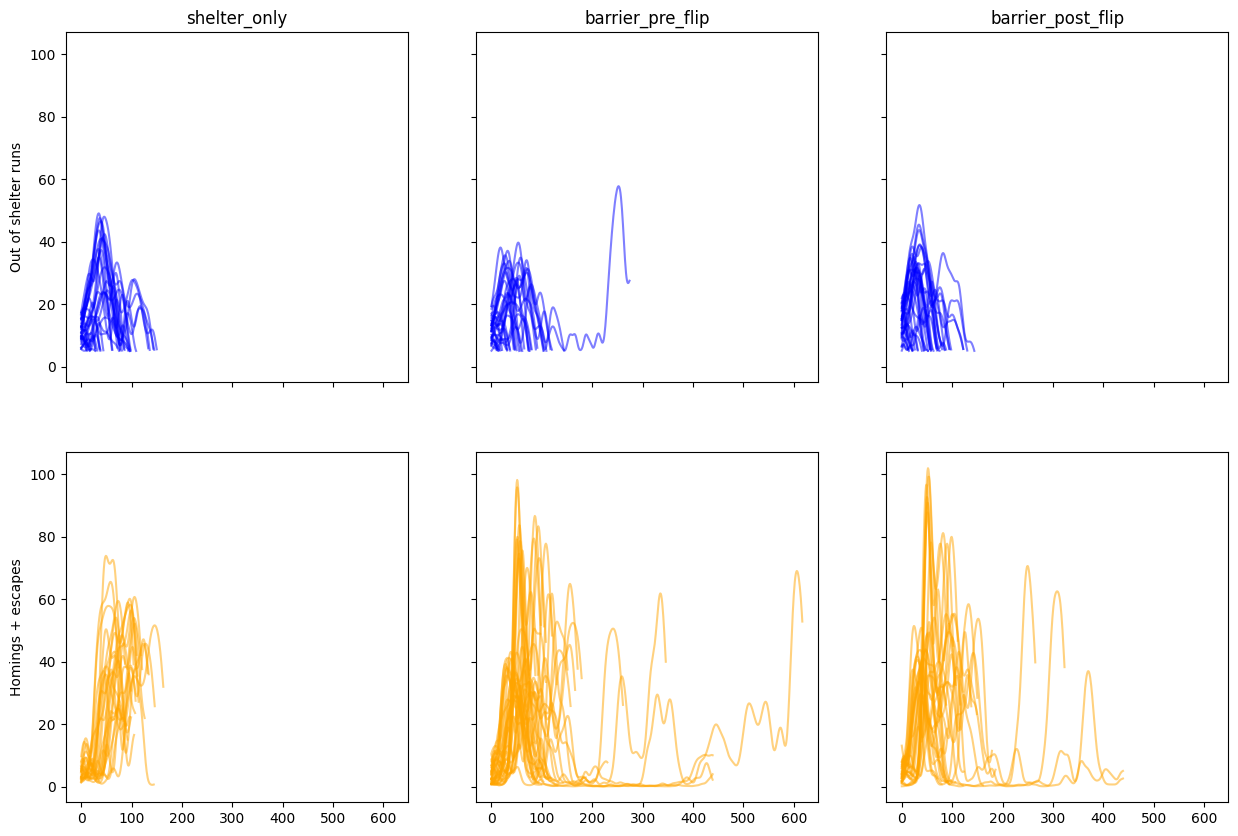

In [86]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for c, cond in enumerate(cond_list):
    frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
    homing_indices = (
        filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
    )
    explore_test_idx = [idx for idx in frames_by_condition_explore if idx in np.where(outside_runs)[0]]
    start = np.concatenate([np.zeros(1), np.where(np.diff(explore_test_idx) > 1)[0] + 1, np.array([len(explore_test_idx)])]).astype(int)
    for s in range(len(start[:-1])):
        axs[0,c].plot(video_df["speed"].to_numpy()[explore_test_idx][start[s]:start[s+1]], color = 'blue', alpha = 0.5)
    axs[0,c].set_title(f"{cond_list[c]}")
    start = np.concatenate([np.zeros(1), np.where(np.diff(homing_indices) > 1)[0] + 1, np.array([len(homing_indices)])]).astype(int)
    for s in range(len(start[:-1])):
        axs[1,c].plot(video_df["speed"].to_numpy()[homing_indices][start[s]:start[s+1]], color = 'orange', alpha = 0.5)
    if c == 0:
        axs[0,c].set_ylabel("Out of shelter runs")
        axs[1,c].set_ylabel("Homings + escapes")

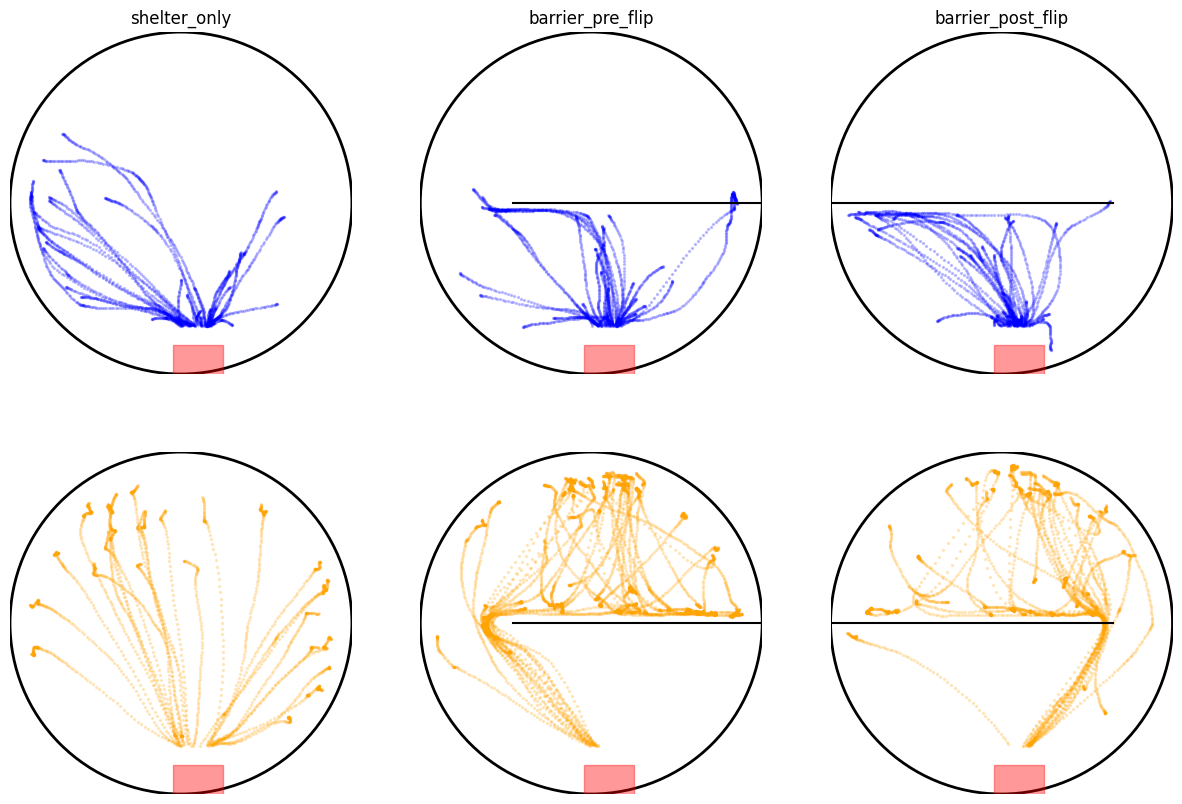

In [81]:
from behave_analysis.utils.arena_plotting import Arena
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for c, cond in enumerate(cond_list):
    frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
    homing_indices = (
        filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
    )
    explore_test_idx = [idx for idx in frames_by_condition_explore if idx in np.where(outside_runs)[0]]
    Arena(ax=axs[0,c], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
    Arena(ax=axs[1,c], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
    axs[0,c].scatter(video_df["mouse_x_position"].to_numpy()[explore_test_idx], video_df["mouse_y_position"].to_numpy()[explore_test_idx], s=2, color = 'blue', alpha = 0.2, label = "Out of shelter runs")
    axs[1,c].scatter(video_df["mouse_x_position"].to_numpy()[homing_indices], video_df["mouse_y_position"].to_numpy()[homing_indices], s=2, color = 'orange', alpha = 0.2, label = "Homings")
    axs[0,c].set_title(f"{cond_list[c]}")
    if c == 0:
        axs[0,c].set_ylabel("Out of shelter runs")
        axs[1,c].set_ylabel("Homings + escapes")

In [ ]:
"""Compare CCA 
1. trained on explore and tested on homings and exploration matched to homings
2. trained on homings and tested on explore and exploration matched to homings"""

method = "balanced_bins_pos"    
# COLUMNS_TO_KEEP, filename = ["hdir", "hdir_velocity", "hdir_velocity", "mouse_x_position", "mouse_y_position", "speed", "acceleration", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"], "cca_results_" + method + ".npz"
# COLUMNS_TO_KEEP, filename = ["mouse_x_position", "mouse_y_position", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"], "cca_pos_results_" + method + ".npz"
# COLUMNS_TO_KEEP, filename = ["hdir", "hsa", "h_preflipbar_a", "h_postflipbar_a"], "cca_angles_results_" + method + ".npz"
COLUMNS_TO_KEEP, filename = ["speed", "acceleration", "hdir_velocity"], "cca_vel_results_" + method + ".npz"

n_components = min(len(COLUMNS_TO_KEEP), 5) # number of CCA components to keep, can't be more than number of behavioral variables
train_explore = {'test_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'train_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'homing_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan)}
train_homing = {'exp_match_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'test_exp_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan), 
                 'train_h_canonical_corr': np.full((len(experiments_objects), 3, n_components), np.nan)}

for e in range(len(experiments_objects)):
    session_name = list(experiments_objects.keys())[e]
    exp = experiments_objects[session_name]
    session = Process(exp).load_session()
    session_start = max(session.shelter_time[0]*60*40, 30*40) # start at shelter_time or 30s, whichever is later
    video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
    fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
    mean_fr = np.nanmean(fcm, axis=0)
    std_fr = np.nanstd(fcm, axis=0)
    fcm_z = (fcm - mean_fr) / std_fr
    assert len(video_df) == fcm.shape[0], "Number of frames in video dataframe does not match number of frames in frame-by-cluster matrix"
    shelter_location = shelter = [np.mean([session.shelter_location[0][0], session.shelter_location[1][0]]), session.shelter_location[0][1]]
    video_df = video_df.with_columns(pl.Series("distance_to_shelter", np.sqrt((video_df["mouse_x_position"] - shelter_location[0])**2 + (video_df["mouse_y_position"] - shelter_location[1])**2)))
    video_df = video_df.with_columns(pl.Series("distance_to_barrier1", np.sqrt((video_df["mouse_x_position"] - session.barrier_location[0][0])**2 + (video_df["mouse_y_position"] - session.barrier_location[0][1])**2)))
    video_df = video_df.with_columns(pl.Series("distance_to_barrier2", np.sqrt((video_df["mouse_x_position"] - session.barrier_location[1][0])**2 + (video_df["mouse_y_position"] - session.barrier_location[1][1])**2)))
    Y, col_names = preprocess_behavioral_data(video_df, COLUMNS_TO_KEEP)

    train_explore["X_train_loadings"] = {session_name:np.full((3, fcm.shape[1], n_components), np.nan)}
    train_explore["X_test_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_explore["X_homing_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_homing["exp_match_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_homing["test_exp_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}
    train_homing["train_h_X_loadings"] = {session_name: np.full((3, fcm.shape[1], n_components), np.nan)}

    for c, cond in enumerate(cond_list):

        explore_train_idx, explore_test_idx, homing_indices = select_train_test_frames(video_df, cond, method = "balanced_bins_pos")
        # check that indices don't fall below the session start time
        explore_train_idx = [idx for idx in explore_train_idx if idx >= session_start]
        explore_test_idx = [idx for idx in explore_test_idx if idx >= session_start]
        homing_indices = [idx for idx in homing_indices if idx >= session_start]

        # FIRST WE TRAIN ON EXPLORE, TEST ON HOMING
        A_X_train = fcm_z[explore_train_idx, :]
        A_Y_train = Y[explore_train_idx, :]
        A_X_test = fcm_z[explore_test_idx, :]
        A_Y_test = Y[explore_test_idx, :]
        B_X_test = fcm_z[homing_indices, :]
        B_Y_test = Y[homing_indices, :]

        # Assuming X_train is (time, neurons) and Y_train is (time, behaviors)
        # 1. Initialize CCA (n_components is the number of correlated pairs to find)
        cca = CCA(n_components=n_components)

        # 2. Fit the model (find the loading vectors)
        cca.fit(A_X_train, A_Y_train)

        # 3. Project the TRAINING data onto the loading vectors
        # X_c and Y_c are the "Canonical Scores"
        X_c, Y_c = cca.transform(A_X_train, A_Y_train)

        # 4. Project the TEST data (using the same weights found during training)
        A_X_test_c, A_Y_test_c = cca.transform(A_X_test, A_Y_test)
        B_X_test_c, B_Y_test_c = cca.transform(B_X_test, B_Y_test)

        # get the canonical correlation
        for i in range(n_components):
            train_explore['test_canonical_corr'][e, c, i] = safe_corrcoef(A_X_test_c[:,i], A_Y_test_c[:,i])
            train_explore['train_canonical_corr'][e, c, i] = safe_corrcoef(X_c[:,i], Y_c[:,i])
            train_explore['homing_canonical_corr'][e, c, i] = safe_corrcoef(B_X_test_c[:,i], B_Y_test_c[:,i])

        # get the loadings for the neurons
        train_explore['X_train_loadings'][session_name][c, :, :] = cca.x_loadings_
        train_explore['X_test_loadings'][session_name][c, :, :] = get_correlation_loadings(A_X_test, A_X_test_c)
        train_explore['X_homing_loadings'][session_name][c, :, :] = get_correlation_loadings(B_X_test, B_X_test_c)

        # SECOND WE TRAIN ON HOMING, TEST ON EXPLORE
        A_X_train = fcm_z[homing_indices, :]
        A_Y_train = Y[homing_indices, :]
        A_X_test = fcm_z[explore_test_idx, :]
        A_Y_test = Y[explore_test_idx, :]
        B_X_test = fcm_z[explore_train_idx, :]
        B_Y_test = Y[explore_train_idx, :]

        # Assuming X_train is (time, neurons) and Y_train is (time, behaviors)
        # 1. Initialize CCA (n_components is the number of correlated pairs to find)
        cca = CCA(n_components=n_components)

        # 2. Fit the model (find the loading vectors)
        cca.fit(A_X_train, A_Y_train)

        # 3. Project the TRAINING data onto the loading vectors
        # X_c and Y_c are the "Canonical Scores"
        X_c, Y_c = cca.transform(A_X_train, A_Y_train)

        # 4. Project the TEST data (using the same weights found during training)
        A_X_test_c, A_Y_test_c = cca.transform(A_X_test, A_Y_test)
        B_X_test_c, B_Y_test_c = cca.transform(B_X_test, B_Y_test)

        # get the canonical correlation
        for i in range(n_components):
            train_homing['exp_match_canonical_corr'][e, c, i] = safe_corrcoef(A_X_test_c[:,i], A_Y_test_c[:,i])
            train_homing['train_h_canonical_corr'][e, c, i] = safe_corrcoef(X_c[:,i], Y_c[:,i])
            train_homing['test_exp_canonical_corr'][e, c, i] = safe_corrcoef(B_X_test_c[:,i], B_Y_test_c[:,i])

        # get the loadings for the neurons
        train_homing['train_h_X_loadings'][session_name][c, :, :] = cca.x_loadings_
        train_homing['exp_match_X_loadings'][session_name][c, :, :] = get_correlation_loadings(A_X_test, A_X_test_c)
        train_homing['test_exp_X_loadings'][session_name][c, :, :] = get_correlation_loadings(B_X_test, B_X_test_c)

path = r"Z:\Jasmine_Laurence\summary_plots\CCA"
results_to_save = {"train_explore": train_explore, 
                   "train_homing": train_homing,
                   "behavioral_var": col_names,
                   "method": "balanced_bins_pos_hdir_speed"}
np.savez(os.path.join(path, filename), **results_to_save, allow_pickle=True)

2026-04-03 13:21:16.114 | WARNING  | behave_analysis.database.computer_ID:get_computer_specific_paths:42 - You sessions is not on winstor or ceph (or you need to reconnect), please check paths!


Meta data file for path JAL004\004_flip_2023_09_03T12_04_16\processed_data\metadata not found, aborting script


SystemExit: 

c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [16]:
path = r"Z:\Jasmine_Laurence\summary_plots\CCA"
results_to_save = {"train_explore": train_explore, 
                   "train_homing": train_homing,
                   "behavioral_var": col_names,
                   "method": "balanced_bins_pos_hdir_speed"}
np.savez(os.path.join(path, "cca_results_balanced_bins_pos_hdir_speed.npz"), **results_to_save, allow_pickle=True)

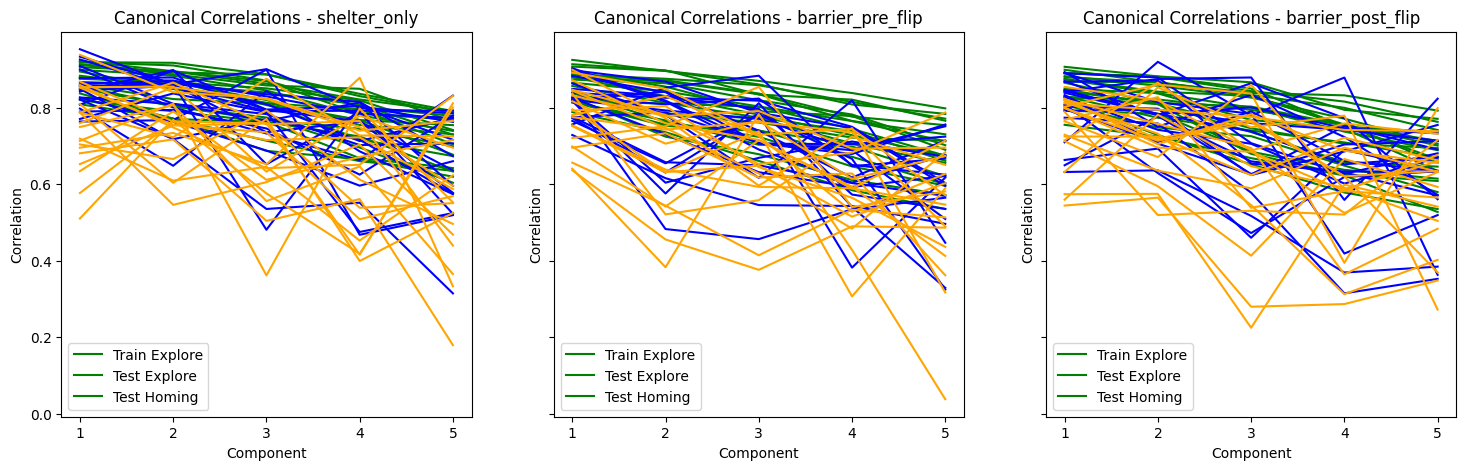

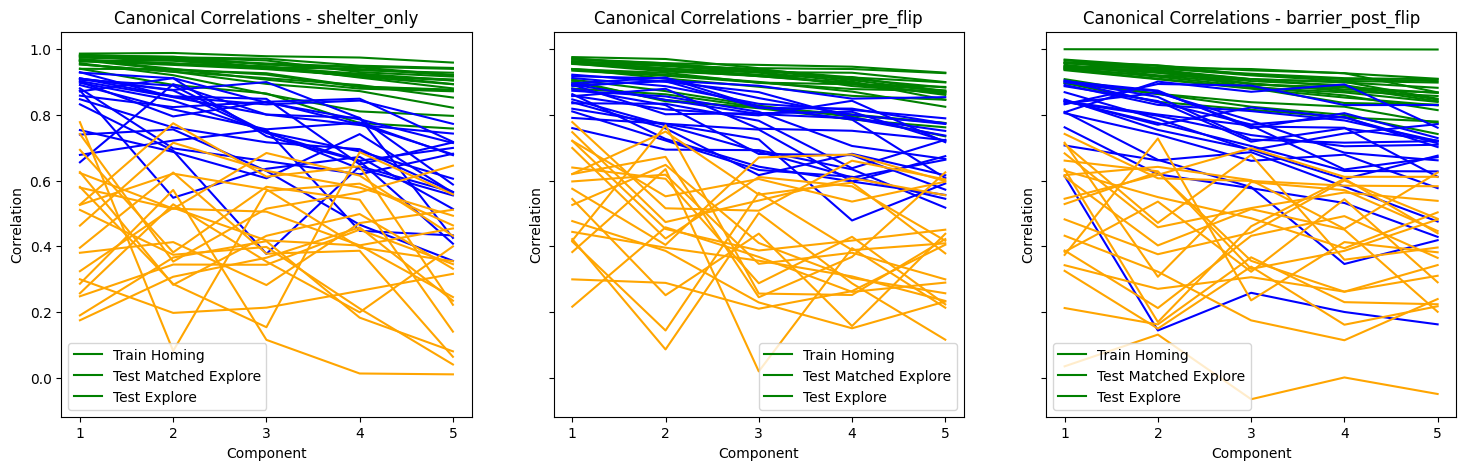

In [6]:
"""Visualize the canonical correlations for train vs test and homing for each condition"""
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for c in range(len(cond_list)):
    axs[c].plot(train_explore['train_canonical_corr'][:, c, :].T, color = 'green')
    axs[c].plot(train_explore['test_canonical_corr'][:, c, :].T, color = 'blue')
    axs[c].plot(train_explore['homing_canonical_corr'][:, c, :].T, color = 'orange')
    axs[c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[c].set_xticks(range(n_components))
    axs[c].set_xticklabels(range(1, n_components+1))
    axs[c].set_xlabel("Component")
    axs[c].set_ylabel("Correlation")
    axs[c].legend(["Train Explore", "Test Explore", "Test Homing"])

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for c in range(3):
    axs[c].plot(train_homing['train_h_canonical_corr'][:, c, :].T, color = 'green')
    axs[c].plot(train_homing['exp_match_canonical_corr'][:, c, :].T, color = 'blue')
    axs[c].plot(train_homing['test_exp_canonical_corr'][:, c, :].T, color = 'orange')
    axs[c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[c].set_xticks(range(n_components))
    axs[c].set_xticklabels(range(1, n_components+1))
    axs[c].set_xlabel("Component")
    axs[c].set_ylabel("Correlation")
    axs[c].legend(["Train Homing", "Test Matched Explore", "Test Explore"])

Text(0.5, 1.0, 'CCA Loadings (Neurons)')

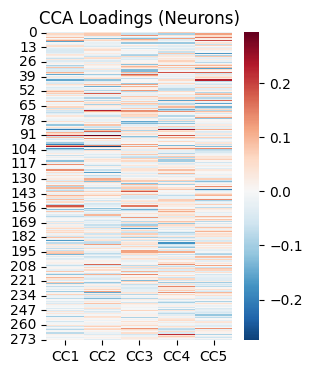

In [119]:
"""Visualize the loadings in a heatmap"""
plt.figure(figsize=(3,4))
sns.heatmap(cca.x_weights_, cmap = "RdBu_r", center=0,
            xticklabels=[f"CC{i+1}" for i in range(cca.n_components)])
plt.title("CCA Loadings (Neurons)")

what to save  
compare loadings  
compare corrcoeff of neural and behav across sesh  
train on homies!  

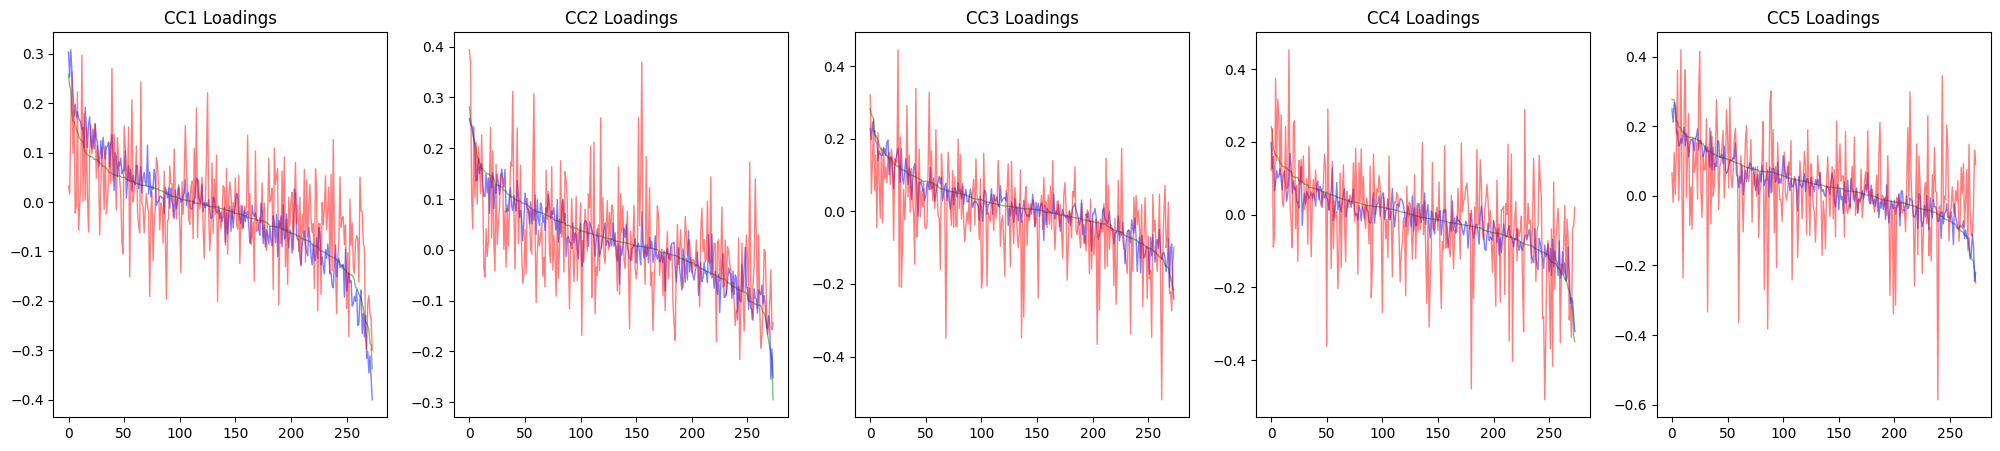

In [12]:
"""Check the loadings"""
X_train_loadings = cca.x_loadings_
X_test_loadings = get_correlation_loadings(A_X_test, A_X_test_c)
X_homie_loadings = get_correlation_loadings(B_X_test, B_X_test_c)

fig, axs = plt.subplots(1, X_train_loadings.shape[1], figsize=(5*X_train_loadings.shape[1], 5))
for i in range(X_train_loadings.shape[1]):
    cc_sorted_indices = np.argsort(X_train_loadings[:,i])[::-1] # sort in descending order
    axs[i].plot(X_train_loadings[cc_sorted_indices,i], label="Train", color = "green", alpha=0.5, linewidth=1)
    axs[i].plot(X_test_loadings[cc_sorted_indices,i], label="Test", color = "blue", alpha=0.5, linewidth=1)
    axs[i].plot(X_homie_loadings[cc_sorted_indices,i], label="Homie", color = "red", alpha=0.5, linewidth=1)
    axs[i].set_title(f"CC{i+1} Loadings")

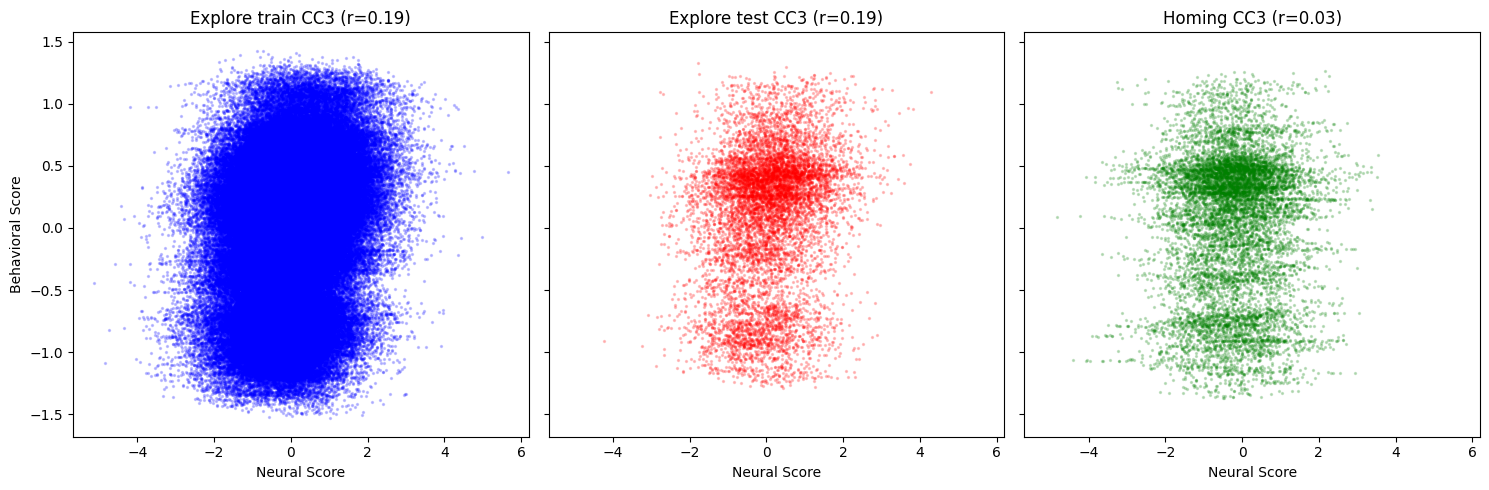

In [134]:
"""Compare the projections of the train and test data on the CCs"""
cc = 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Train Plot
axes[0].scatter(X_c[:, cc], Y_c[:, cc], alpha=0.2, c='blue', s=2)
axes[0].set_title(f"Explore train CC{cc+1} (r={np.corrcoef(X_c[:,cc], Y_c[:,cc])[0,1]:.2f})")
axes[0].set_xlabel("Neural Score")
axes[0].set_ylabel("Behavioral Score")

# Test Plot
axes[1].scatter(A_X_test_c[:, cc], A_Y_test_c[:, cc], alpha=0.2, c='red', s=2)
axes[1].set_title(f"Explore test CC{cc+1} (r={np.corrcoef(A_X_test_c[:,cc], A_Y_test_c[:,cc])[0,1]:.2f})")
axes[1].set_xlabel("Neural Score")

# Homie Plot
axes[2].scatter(B_X_test_c[:, cc], B_Y_test_c[:, cc], alpha=0.2, c='green', s=2)
axes[2].set_title(f"Homing CC{cc+1} (r={np.corrcoef(B_X_test_c[:,cc], B_Y_test_c[:,cc])[0,1]:.2f})")
axes[2].set_xlabel("Neural Score")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Condition B (Homings/Escapes)')

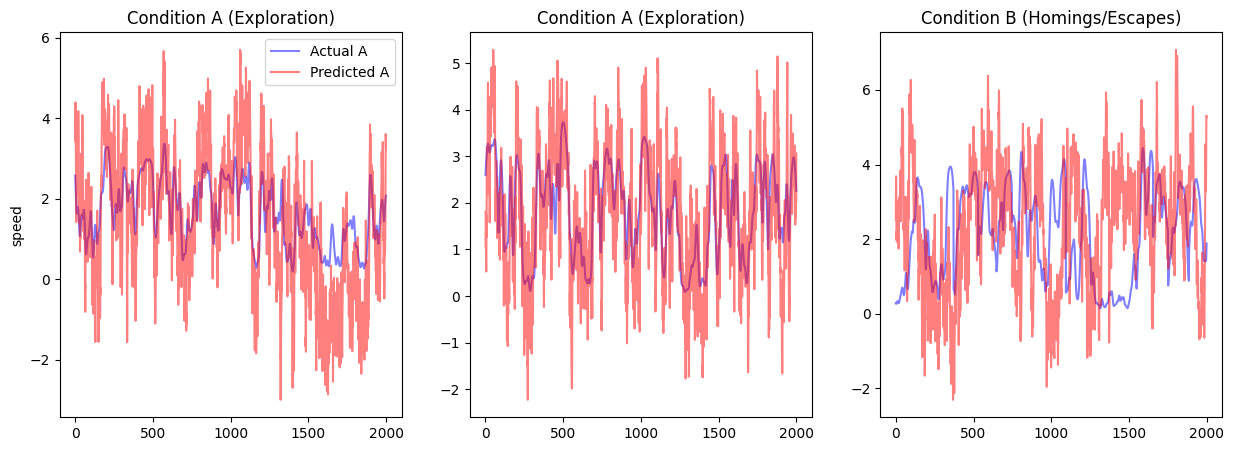

In [91]:
n_time = [1000,3000]
variable = "speed"

if variable == "speed":
    Y_train = A_Y_train[n_time[0]:n_time[1],np.where(col_names == "speed")[0][0]]
    Y_train_hat = A_Y_train_pred[n_time[0]:n_time[1],np.where(col_names == "speed")[0][0]]
    Y_test = A_Y_test[n_time[0]:n_time[1],np.where(col_names == "speed")[0][0]]
    Y_test_hat = A_Y_test_pred[n_time[0]:n_time[1],np.where(col_names == "speed")[0][0]]
    Y_test_B = B_Y_test[n_time[0]:n_time[1],np.where(col_names == "speed")[0][0]]
    Y_test_B_hat = B_Y_test_pred[n_time[0]:n_time[1],np.where(col_names == "speed")[0][0]]
# elif variable in ["hdir", "hsa", "h_preflipbar_a", "h_postflipbar_a"]:

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(Y_train, color = 'blue', alpha=0.5, label='Actual A')
axs[0].plot(Y_train_hat, color = 'red', alpha=0.5, label='Predicted A')
axs[0].set_title("Condition A (Exploration)")
axs[0].set_ylabel(variable)
axs[0].legend()
axs[1].plot(Y_test, color = 'blue', alpha=0.5, label='Actual A')
axs[1].plot(Y_test_hat, color = 'red', alpha=0.5, label='Predicted A')
axs[1].set_title("Condition A (Exploration)")
axs[2].plot(Y_test_B, color = 'blue', alpha=0.5, label='Actual B')
axs[2].plot(Y_test_B_hat, color = 'red', alpha=0.5, label='Predicted B')
axs[2].set_title("Condition B (Homings/Escapes)")
